In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
iyr=1980;fyr=2024
domain='GRf'
domain_2 = 'GRp'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [3]:
domain_2 = 'GRp'
domain_3 = 'GRp_bug'

In [4]:
# Fedchenko area
#lon
w=24 ; x=34
#lat
y=40 ; z=52

In [5]:
# Ice thresold, 2025_28_11_Grp*.nc
ice_threshold = 40

In [6]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [7]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_3 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [8]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [9]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [101]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)
# index 1D du minimum
idx_1d = dist.argmin().item()
# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())

Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781


### Loading the SEB variables

In [11]:
# Latent Heat Flux (W/m2)
variable='LHF' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_LHF = ds[:,k:-k,k:-k]

In [12]:
# Sensible Heat Flux (W/m2)
variable='SHF' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SHF = ds[:,k:-k,k:-k]

# Nouvelles VARIABLES à CHARGER

#### Variables RZ, MBRTOP, et MBMTOP pas extraites des simues bug et sans bug

In [ ]:
## Plutot utiliser :       
# float MBRTOP(TIME, SECTOR, Y, X) ;
        #         MBRTOP:units = "mmWE" ;
        #         MBRTOP:long_name = "Refreezing, only top layer" ;
        #         MBRTOP:history = "From ICE.p20.2022.01.01-31" ;


# Refreezing (mmWE/mois)
# variable='RZ' 

# fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
# ds= xr.open_dataset(sourceData_1+fileNameF)[variable].isel(SECTOR1_1=0).load()

# ds = ds.assign_coords(X=np.round(ds.X.values))
# ds = ds.assign_coords(Y=np.round(ds.Y.values))
# ds = ds.rename({'TIME': 'time'})

# # Enlever k pixels sur les contours
# ds_RZ = ds[:,k:-k,k:-k]

# # Computing energy flux related to melt (W/m2)
# Lf = 3.34*10**5 # J.kg**(-1) the latent heat of fusion of water
# ### APPROX HERE need to calculate the exact value for each month, because month duration vary
# t_timestep = 60*60*24*365.5/12 # 60*60*24 seconds in a month

# ds_RZ = ds_RZ  * Lf / t_timestep /1000 

In [28]:
## Plutot utiliser :       
# float MBMTOP(TIME, SECTOR, Y, X) ;
        #         MBMTOP:units = "mmWE" ;
        #         MBMTOP:long_name = "Only Melting, only top layer" ;
        #         MBMTOP:history = "From ICE.p20.2022.01.01-31" ;

# Melt (mmWE/mois)
variable='ME' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].isel(SECTOR1_1=0).load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds[:,k:-k,k:-k]

ds_ME = - ds_ME # sign minus because energy is lost by  the surface


# Computing energy flux related to melt (W/m2)
Lf = 3.34*10**5 # J.kg**(-1) the latent heat of fusion of water
### APPROX HERE need to calculate the exact value for each month, because month duration vary
t_timestep = 60*60*24*365.5/12 # 60*60*24 seconds in a month

ds_ME = ds_ME  * Lf / t_timestep /1000 

In [14]:
# Long Wave Downward (W/m2)
variable='LWD' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_LWD = ds[:,k:-k,k:-k]

In [15]:
# Long Wave Upward (W/m2)
variable='LWU' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_LWU = ds[:,k:-k,k:-k]

In [24]:
# Net long Wave radiation (W/m2)
ds_NLW = ds_LWD - ds_LWU

In [16]:
# Short Wave Downward (W/m2)
variable='SWD' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SWD = ds[:,k:-k,k:-k]

In [17]:
# Short Wave Upward (W/m2)
variable='SWU' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SWU = ds[:,k:-k,k:-k]

In [22]:
# Net Short Wave radiation (W/m2)
ds_NSW = ds_SWD - ds_SWU

In [30]:
# Ground Flux (W/m2)
variable='GF' 

fileNameF= variable+'_monmean_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds= xr.open_dataset(sourceData_1+fileNameF)[variable].load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_GF = ds[:,k:-k,k:-k]

# Negative flux because it is going away from the surface 
ds_GF = -ds_GF

In [31]:
seb_dataset = {
    "SHF": ds_SHF,
    "LHF": ds_LHF,
    "ME":  ds_ME,
    "NLW": ds_NLW,
    "NSW": ds_NSW,
    "GF":  ds_GF,
}

### Composantes du SEB au point de grille du forage 2025

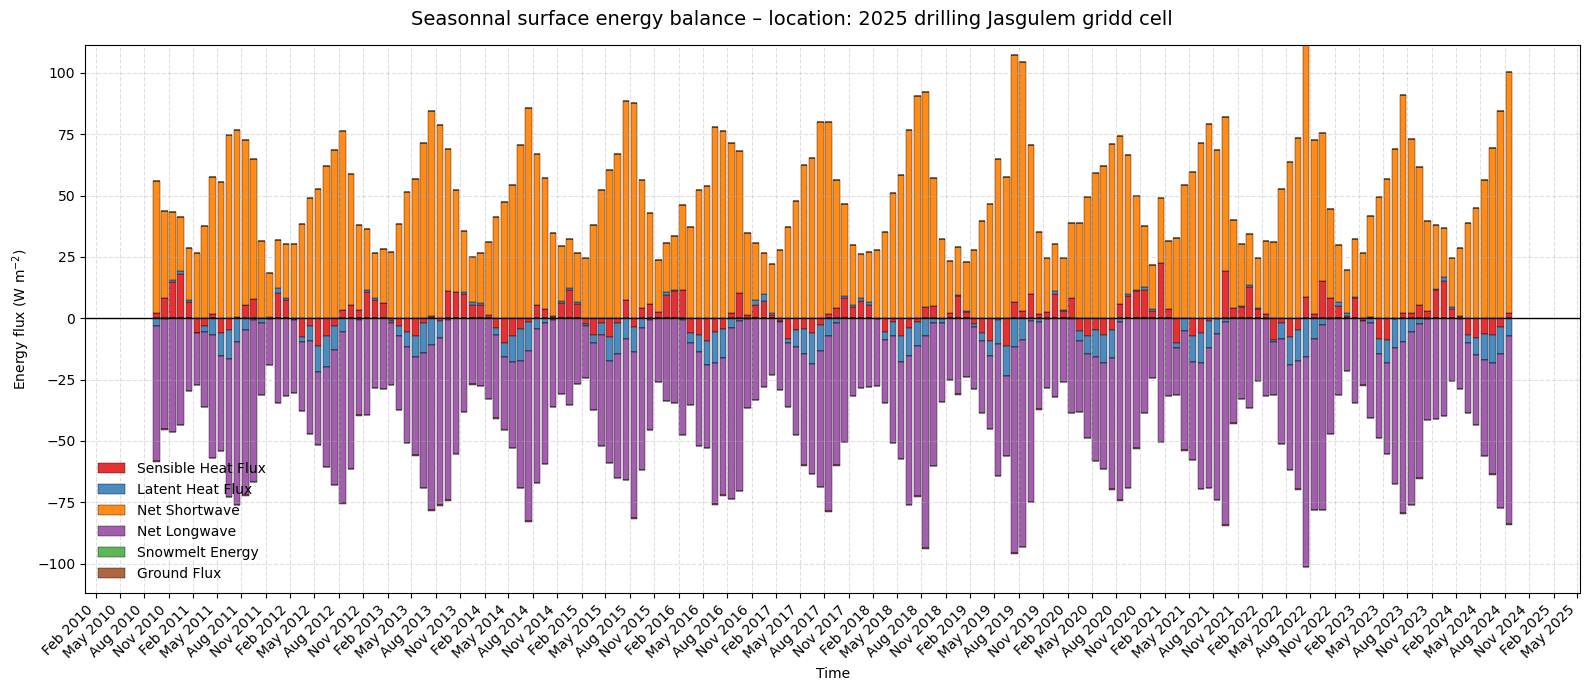

In [148]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SEB
components = ["SHF", "LHF", "NSW", "NLW", "ME", "GF"]
labels = {
    "SHF": "Sensible Heat Flux",
    "LHF": "Latent Heat Flux",
    "NSW": "Net Shortwave",
    "NLW": "Net Longwave",
    "ME": "Snowmelt Energy",
    "GF": "Ground Flux"
}

# Couleurs pour les histos
colors = {
    "SHF": "#e41a1c",  
    "LHF": "#377eb8",  
    "NSW": "#ff7f00", 
    "NLW": "#984ea3", 
    "ME":  "#4daf4a",  
    "GF":  "#a65628"   
}

# Temps et données
time = seb_jasg[components[0]].time.values
data = np.array([seb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface energy balance – location: 2025 drilling Jasgulem gridd cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

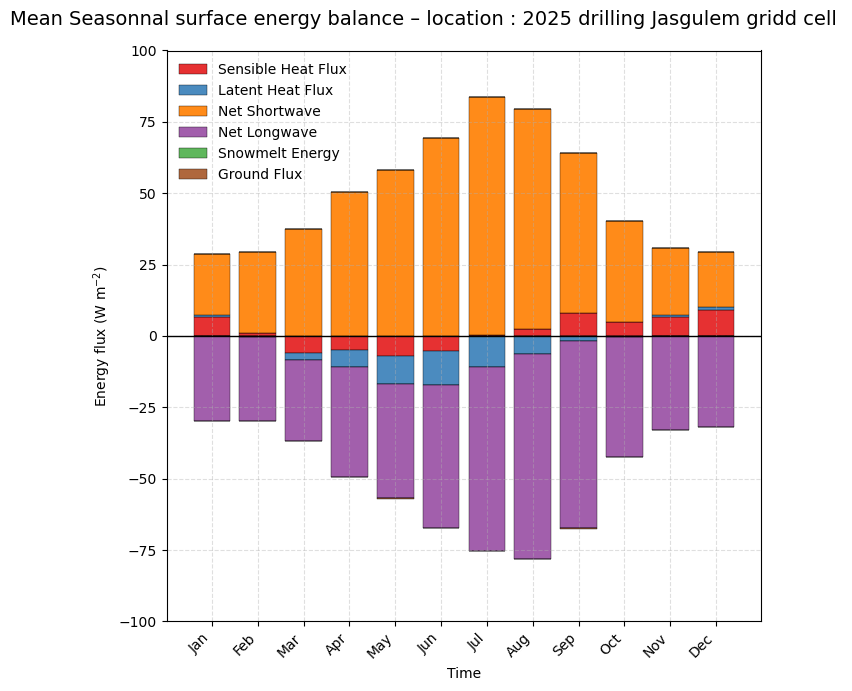

In [149]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=iY, X=iX)

# Moyennes mensuelles
seb_clim = {}
for comp in components:
    seb_clim[comp] = seb_jasg[comp].groupby("time.month").mean()

# Composantes du SEB
components = ["SHF", "LHF", "NSW", "NLW", "ME", "GF"]
labels = {
    "SHF": "Sensible Heat Flux",
    "LHF": "Latent Heat Flux",
    "NSW": "Net Shortwave",
    "NLW": "Net Longwave",
    "ME": "Snowmelt Energy",
    "GF": "Ground Flux"
}

# Couleurs pour les histos
colors = {
    "SHF": "#e41a1c",  
    "LHF": "#377eb8", 
    "NSW": "#ff7f00",  
    "NLW": "#984ea3",  
    "ME":  "#4daf4a", 
    "GF":  "#a65628"   
}

# Temps et données
months = np.arange(1, 13)
data = np.array([seb_clim[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(7, 7))


ax.set_xticks(months)

ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

cumulative_pos = np.zeros(12)
cumulative_neg = np.zeros(12)

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        months,
        pos,
        width=0.8,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        months,
        neg,
        width=0.8,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")
ax.set_ylim(-100, 100)

# Format date

plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Mean Seasonnal surface energy balance – location : 2025 drilling Jasgulem gridd cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1736400/2273003536.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


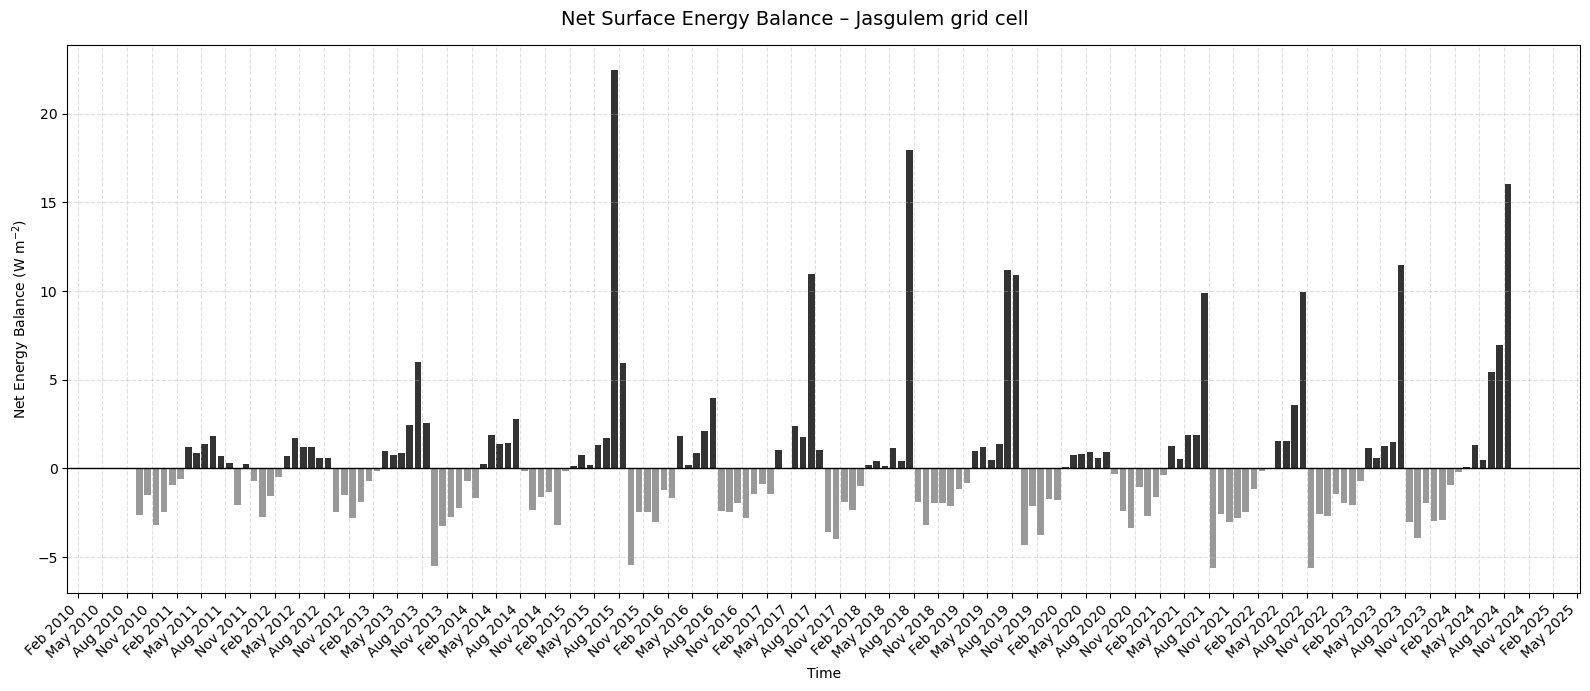

In [118]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=iY, X=iX)

# Calcul de la résultante du SEB
seb_net = (
    seb_jasg["SHF"]
    + seb_jasg["LHF"]
    + seb_jasg["NSW"]
    + seb_jasg["NLW"]
    + seb_jasg["ME"]
    + seb_jasg["GF"]
)


# Temps et données
time = seb_net.time.values
values = seb_net.values

fig, ax = plt.subplots(figsize=(16, 7))

pos = np.where(values > 0, values, 0)
neg = np.where(values < 0, values, 0)

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

ax.bar(
    time,
    pos,
    width=width,
    color="black",
    alpha=0.8,
)

ax.bar(
    time,
    neg,
    width=width,
    color="gray",
    alpha=0.8,
)

ax.axhline(0, color="black", linewidth=1)

ax.set_ylabel("Net Energy Balance (W m$^{-2}$)")
ax.set_xlabel("Time")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Net Surface Energy Balance – Jasgulem grid cell", fontsize=14)

plt.tight_layout()
plt.show()

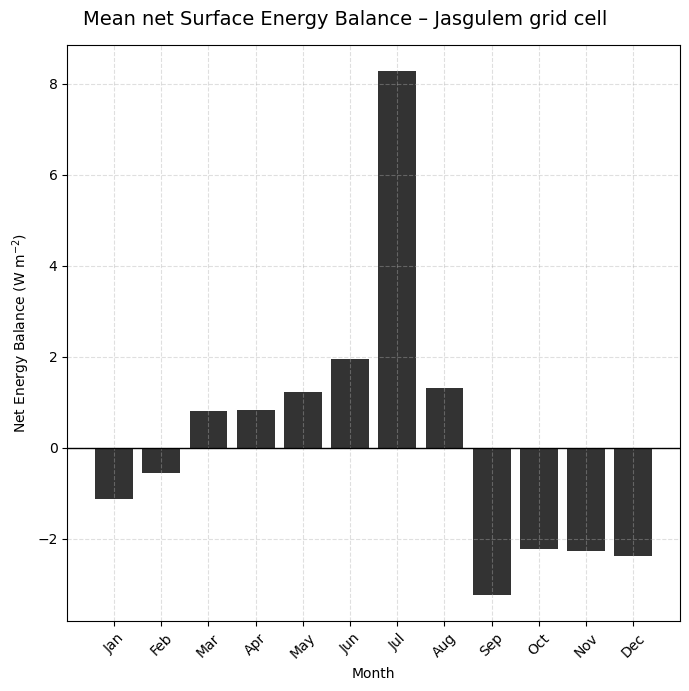

In [128]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=iY, X=iX)

# Calcul SEB net
seb_net = (
    seb_jasg["SHF"]
    + seb_jasg["LHF"]
    + seb_jasg["NSW"]
    + seb_jasg["NLW"]
    + seb_jasg["ME"]
    + seb_jasg["GF"]
)

# Climatologie mensuelle
seb_net = seb_net.groupby("time.month").mean()

# Données pour plot
months = np.arange(1, 13)
values = seb_net.values

fig, ax = plt.subplots(figsize=(7, 7))

ax.bar(
    months,
    values,
    width=0.8,
    color="black",
    alpha=0.8
)

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(months)
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=45
)

ax.set_ylabel("Net Energy Balance (W m$^{-2}$)")
ax.set_xlabel("Month")

ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Mean net Surface Energy Balance – Jasgulem grid cell", fontsize=14)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-SEP' is deprecated and will be removed in a future version, please use 'YS-SEP' instead.
  self.index_grouper = pd.Grouper(


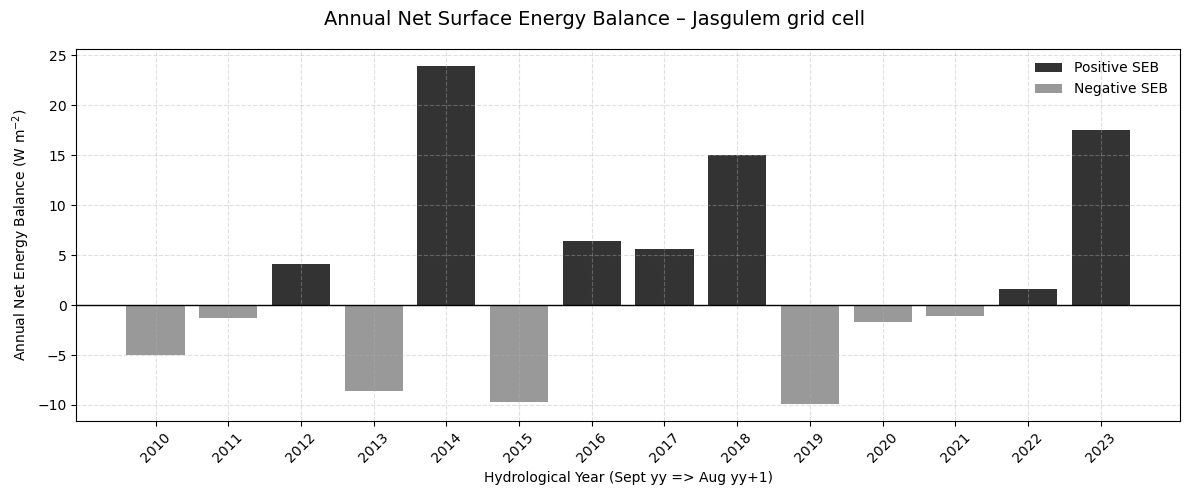

In [141]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrage temporel
seb_filtered = {
    key: da.sel(time=slice(start_date, end_date))
    for key, da in seb_dataset.items()
}

# extraction pixel
seb_jasg = {
    key: da.isel(Y=iY, X=iX)
    for key, da in seb_filtered.items()
}

# SEB net
seb_net = (
    seb_jasg["SHF"]
    + seb_jasg["LHF"]
    + seb_jasg["NSW"]
    + seb_jasg["NLW"]
    + seb_jasg["ME"]
    + seb_jasg["GF"]
)

# =========================
# AGRÉGATION ANNUELLE (HYDRO YEAR SEP→AUG)
# =========================

seb_yearly = seb_net.resample(time="AS-SEP").sum()

# conversion propre des axes
years = seb_yearly["time.year"].values
values = seb_yearly.values

# =========================
# PLOT
# =========================

fig, ax = plt.subplots(figsize=(12, 5))

pos = np.where(values > 0, values, 0)
neg = np.where(values < 0, values, 0)

ax.bar(years, pos, color="black", alpha=0.8)
ax.bar(years, neg, color="gray", alpha=0.8)

ax.axhline(0, color="black", linewidth=1)

ax.set_ylabel("Annual Net Energy Balance (W m$^{-2}$)")
ax.set_xlabel("Hydrological Year (Sept yy => Aug yy+1)")

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Annual Net Surface Energy Balance – Jasgulem grid cell", fontsize=14)

plt.tight_layout()
plt.show()

Indice Y : 26
Indice X : 47


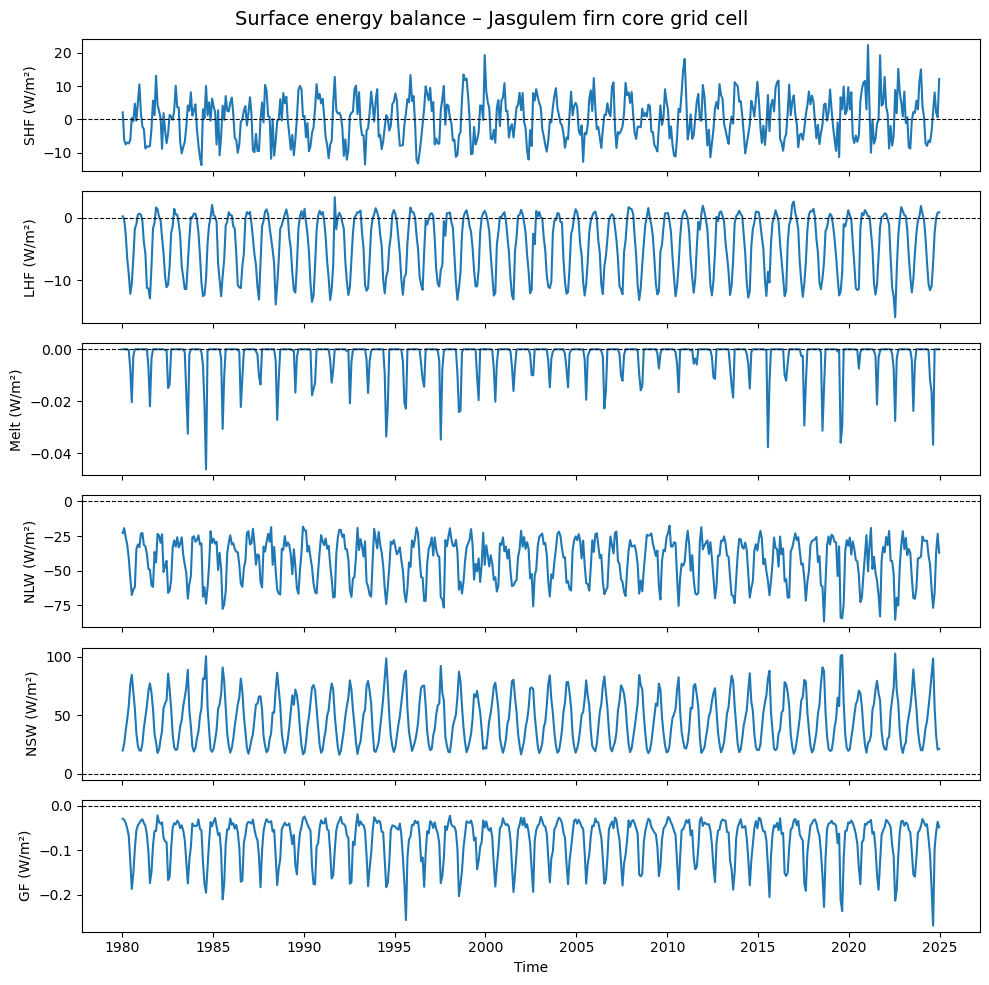

In [104]:
print("Indice Y :", iY)
print("Indice X :", iX)

fig, axes = plt.subplots(
    nrows=6,
    ncols=1,
    figsize=(10, 10),
    sharex=True
)

datasets = [
    ds_SHF, ds_LHF, ds_ME, ds_NLW,
    ds_NSW, ds_GF
]

ylabels = [
    "SHF (W/m²)", "LHF (W/m²)", "Melt (W/m²)",
    "NLW (W/m²)",
    "NSW (W/m²)",
    "GF (W/m²)"
]

# plots
for i, (ax, ds, yl) in enumerate(zip(axes, datasets, ylabels)):
    ds.isel(Y=iY, X=iX).plot(
        ax=ax,
    )
    ax.set_ylabel(yl)
    ax.set_title("")
    ax.set_xlabel("")
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")

axes[-1].set_xlabel("Time")

# Titre global
fig.suptitle(
    f"Surface energy balance – Jasgulem firn core grid cell ",
    fontsize=14
)

plt.subplots_adjust(top=0.93)
plt.tight_layout()
plt.show()

Indice Y : 26
Indice X : 47


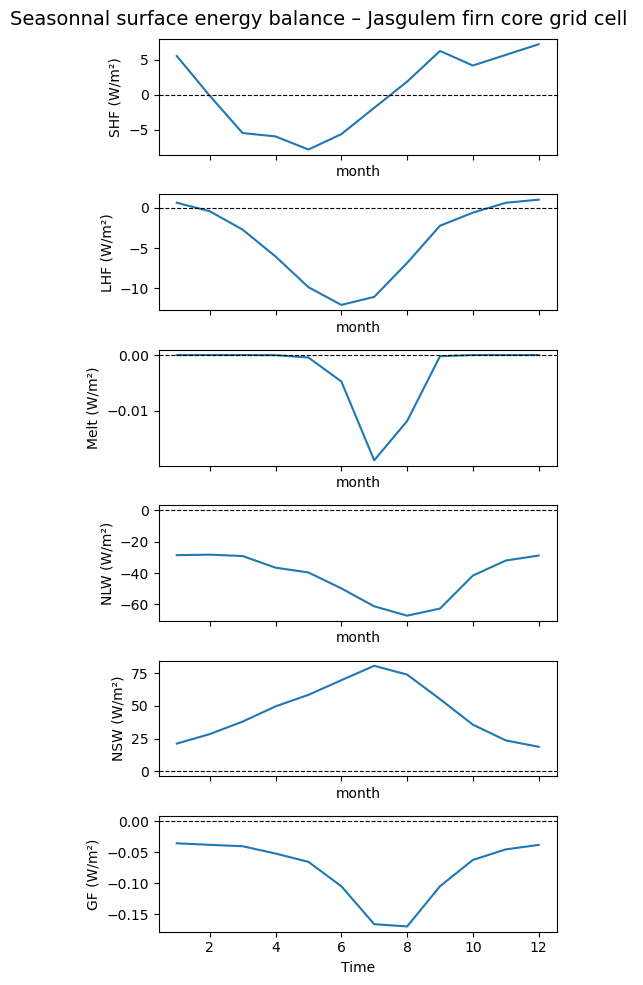

In [105]:
print("Indice Y :", iY)
print("Indice X :", iX)

fig, axes = plt.subplots(
    nrows=6,
    ncols=1,
    figsize=(5, 10),
    sharex=True
)

datasets = [
    ds_SHF.groupby('time.month').mean('time', skipna=True), 
    ds_LHF.groupby('time.month').mean('time', skipna=True), 
    ds_ME.groupby('time.month').mean('time', skipna=True), 
    ds_NLW.groupby('time.month').mean('time', skipna=True),
    ds_NSW.groupby('time.month').mean('time', skipna=True),
    ds_GF.groupby('time.month').mean('time', skipna=True)
]

ylabels = [
    "SHF (W/m²)", "LHF (W/m²)", "Melt (W/m²)",
    "NLW (W/m²)",
    "NSW (W/m²)",
    "GF (W/m²)"
]

# plots
for i, (ax, ds, yl) in enumerate(zip(axes, datasets, ylabels)):
    ds.isel(Y=iY, X=iX).plot(
        ax=ax,
    )

    ax.set_ylabel(yl)
    ax.set_title("")
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")

axes[-1].set_xlabel("Time")

fig.suptitle(
    f"Seasonnal surface energy balance – Jasgulem firn core grid cell ",
    fontsize=14
)

plt.subplots_adjust(top=0.93)
plt.tight_layout()
plt.show()


### Composantes du SEB sur les 2x2 mailles Nord-Ouest du forage 2025

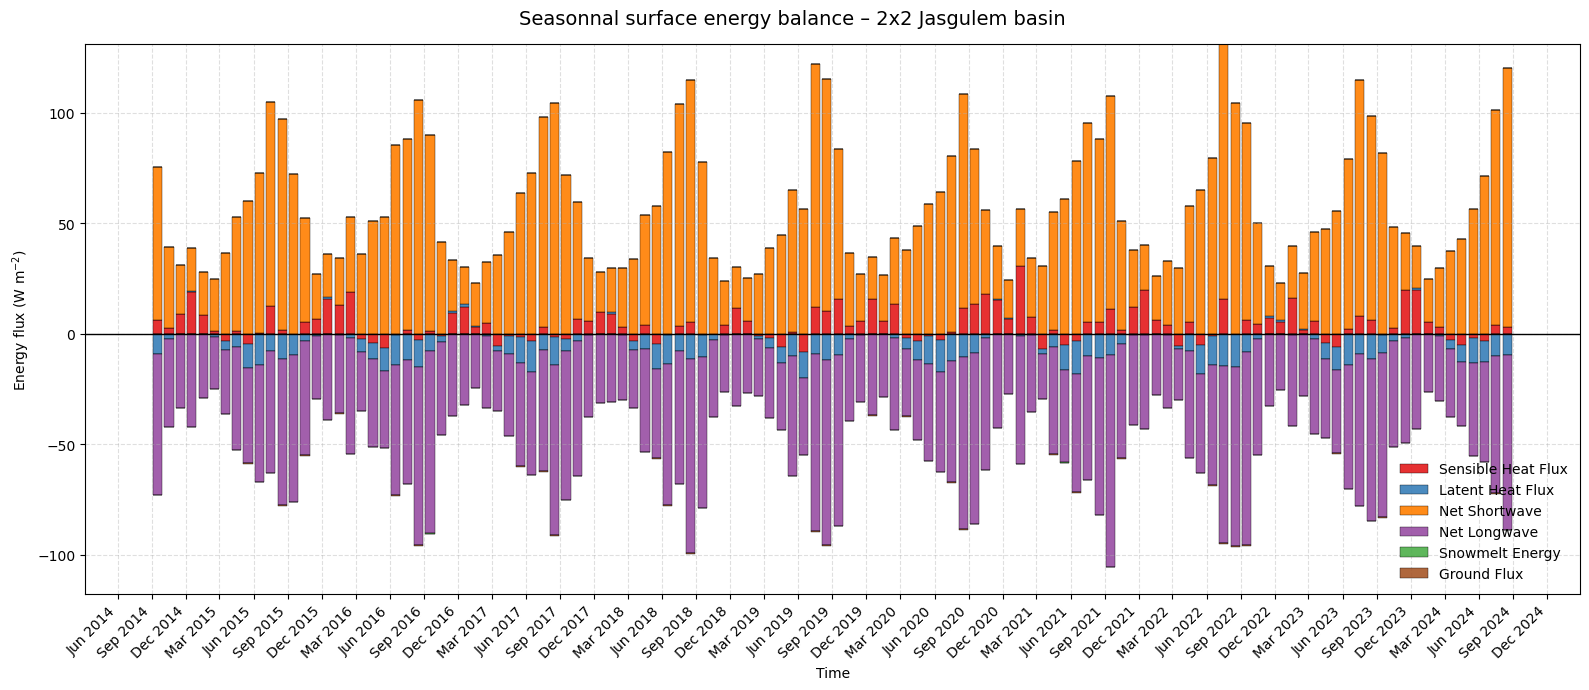

In [109]:
# Période cible
start_date = "2014-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=slice(iY, iY+2), X=slice(iX-1, iX+1)).mean(dim=("Y", "X"))

# Composantes du SEB
components = ["SHF", "LHF", "NSW", "NLW", "ME", "GF"]
labels = {
    "SHF": "Sensible Heat Flux",
    "LHF": "Latent Heat Flux",
    "NSW": "Net Shortwave",
    "NLW": "Net Longwave",
    "ME": "Snowmelt Energy",
    "GF": "Ground Flux"
}

# Couleurs pour les histos
colors = {
    "SHF": "#e41a1c",  # rouge (chaleur sensible)
    "LHF": "#377eb8",  # bleu (latent)
    "NSW": "#ff7f00",  # orange (rayonnement solaire)
    "NLW": "#984ea3",  # violet (IR)
    "ME":  "#4daf4a",  # vert (fonte neige)
    "GF":  "#a65628"   # marron (sol)
}

# Temps et données
time = seb_jasg[components[0]].time.values
data = np.array([seb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface energy balance – 2x2 Jasgulem basin ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Composantes du SEB pour l'ensemble du glacier Fedchenko ?

In [88]:
ds_ICE_expanded = ds_ICE.expand_dims({"time": ds_LHF.time}).transpose("time", "Y", "X")

In [89]:
ds_ICE_Fed = ds_ICE[w:x,y:z]
ds_lon_Fed = ds_lon[w:x,y:z]
ds_lat_Fed = ds_lat[w:x,y:z]
ds_SH_Fed = ds_SH[w:x,y:z]

In [90]:
print('min atitude of selected Fechenko glacier area: ', ds_SH_Fed.min())
print('max atitude of selected Fechenko glacier area: ', ds_SH_Fed.max())
print('mean atitude of selected Fechenko glacier area: ', ds_SH_Fed.mean(skipna=True))
count = np.count_nonzero(~np.isnan(ds_SH_Fed))
count_all = ds_SH_Fed.size
print('mean atitude of selected Fechenko glacier area: ',count)
print('mean atitude of selected Fechenko glacier area: ',count_all)

min atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(2857.7615, dtype=float32)
max atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(5668.944, dtype=float32)
mean atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(4452.6855, dtype=float32)
mean atitude of selected Fechenko glacier area:  120
mean atitude of selected Fechenko glacier area:  120


In [95]:
ds_Fed = xr.Dataset({
    name: xr.where(ds_ICE_expanded > ice_threshold, ds, np.nan)
    for name, ds in seb_dataset.items()
}).isel(X=slice(w, x), Y=slice(y, z))
#dsF['ME']